# Decision trees

Two course colabs on regression trees and two on classification trees, in one notebook.

A decision tree splits the data with a sequence of yes/no questions on single features
("is MedInc <= 5.0?") and predicts the average target of the training samples that end up in the same leaf.
It can capture non-linear patterns and interactions without any feature engineering, and a small tree is
easy to read.

Part 1 is regression on California housing with `DecisionTreeRegressor`:

1. a shallow tree and how to visualise it
2. how depth controls under/overfitting
3. tuning `max_depth` and `min_samples_split`
4. cost complexity pruning
5. feature importances

Part 2 is classification with `DecisionTreeClassifier`, on iris and abalone.

# Part 1: regression trees

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, ShuffleSplit, cross_validate,
                                     validation_curve, GridSearchCV)
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

np.random.seed(306)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

In [2]:
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, random_state=42)

## A shallow tree

No scaling here. Trees split on one feature at a time using thresholds, so scaling doesn't change the
model at all, and leaving the features in their original units means the split thresholds can be read
directly. (The course colab had a `StandardScaler` in the pipeline, which made the tree print rules like
`feature_0 <= 0.62`.)

In [3]:
tree3 = DecisionTreeRegressor(max_depth=3, random_state=42)

res = cross_validate(tree3, train_features, train_labels, cv=cv,
                     scoring="neg_mean_absolute_error", return_train_score=True)
print(f"train MAE: {-res['train_score'].mean():.3f} +/- {res['train_score'].std():.3f}")
print(f"valid MAE: {-res['test_score'].mean():.3f} +/- {res['test_score'].std():.3f}")

train MAE: 0.590 +/- 0.005
valid MAE: 0.591 +/- 0.003


About 0.59, worse than linear regression (0.53). With only 8 leaves the model can only predict 8 different
values. Train and validation are equal, so it's underfitting.

### As a diagram

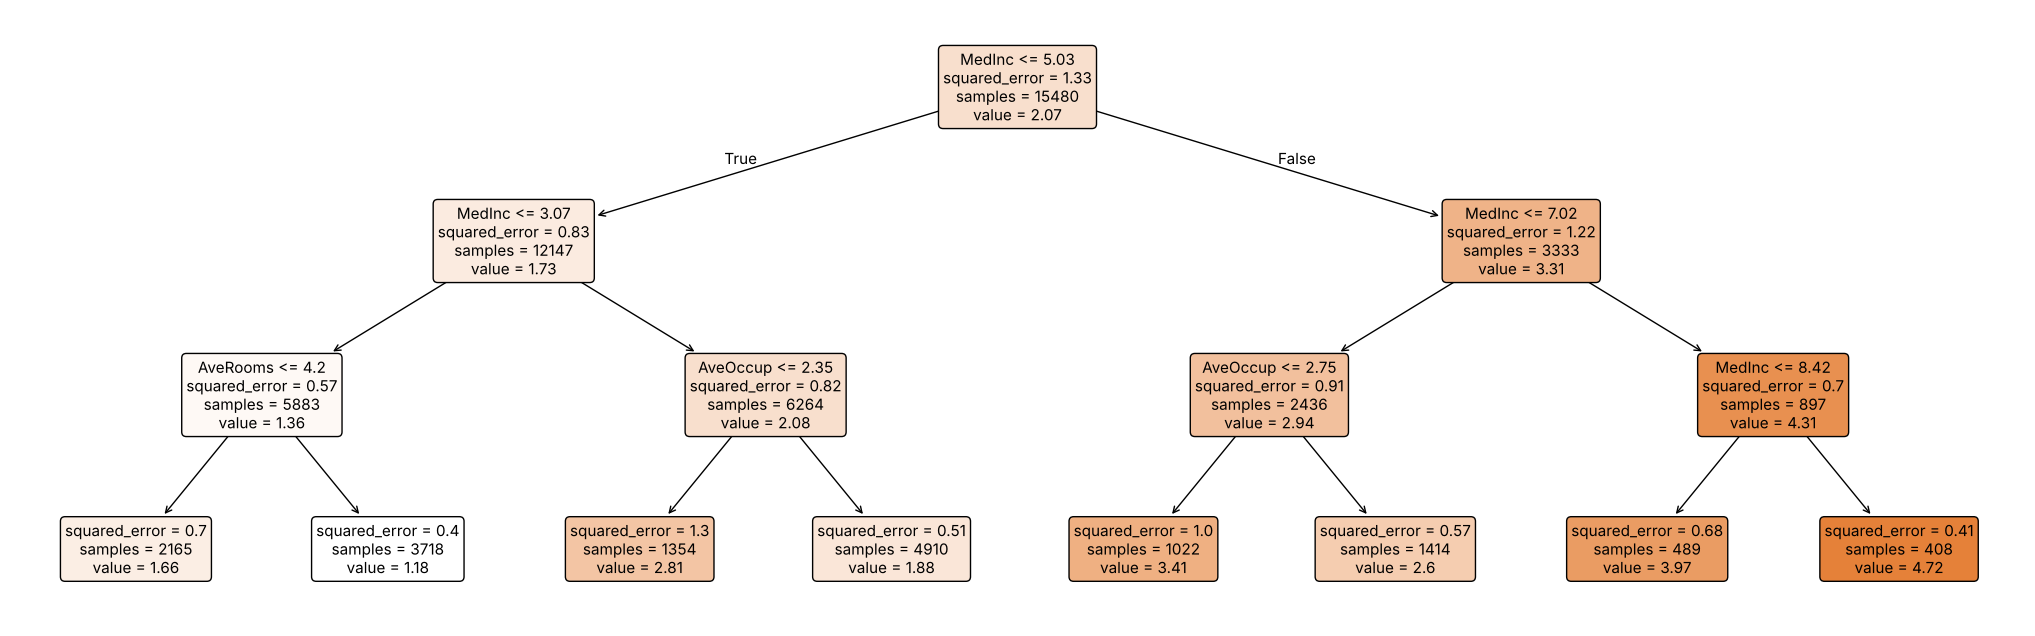

In [4]:
tree3.fit(train_features, train_labels)

plt.figure(figsize=(26, 8))
plot_tree(tree3, feature_names=features.columns, rounded=True, filled=True, fontsize=11, precision=2)
plt.show()

Each box shows the split rule, the `squared_error` (variance of the target in that node), how many
samples reached it, and `value`, the mean target there, which is the prediction if it's a leaf.
Darker colour = higher predicted value.

### As text

In [5]:
print(export_text(tree3, feature_names=list(features.columns), decimals=2))

|--- MedInc <= 5.03
|   |--- MedInc <= 3.07
|   |   |--- AveRooms <= 4.20
|   |   |   |--- value: [1.66]
|   |   |--- AveRooms >  4.20
|   |   |   |--- value: [1.18]
|   |--- MedInc >  3.07
|   |   |--- AveOccup <= 2.35
|   |   |   |--- value: [2.81]
|   |   |--- AveOccup >  2.35
|   |   |   |--- value: [1.88]
|--- MedInc >  5.03
|   |--- MedInc <= 7.02
|   |   |--- AveOccup <= 2.75
|   |   |   |--- value: [3.41]
|   |   |--- AveOccup >  2.75
|   |   |   |--- value: [2.60]
|   |--- MedInc >  7.02
|   |   |--- MedInc <= 8.42
|   |   |   |--- value: [3.97]
|   |   |--- MedInc >  8.42
|   |   |   |--- value: [4.72]



Reading it: the first split is on income at about 5.0 (i.e. $50k). Low income blocks are split again on
income and then on AveRooms or AveOccup, high income blocks on income again and on AveOccup. The top
leaf (MedInc > 8.42) predicts 4.72, i.e. $472k. Income dominates, which matches the
correlations from the EDA.

### What the predictions look like

A tree's prediction is a step function. Easiest to see with a single feature:

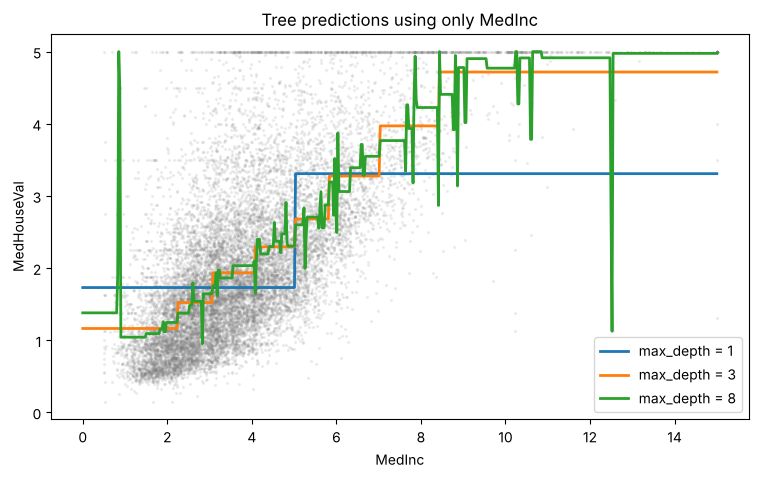

In [6]:
x = train_features[['MedInc']]
grid = pd.DataFrame({'MedInc': np.linspace(0, 15, 600)})

plt.figure(figsize=(9, 5))
plt.scatter(x, train_labels, s=2, alpha=0.1, c='grey')
for depth in [1, 3, 8]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(x, train_labels)
    plt.plot(grid['MedInc'], t.predict(grid), lw=2, label=f'max_depth = {depth}')
plt.xlabel('MedInc'); plt.ylabel('MedHouseVal'); plt.legend()
plt.title('Tree predictions using only MedInc')
plt.show()

Depth 1 is one step, depth 3 is 8 steps, depth 8 has up to 256 and starts chasing individual groups of
points.

## Evaluation on the test set

In [7]:
def report(model, X, y):
    pred = model.predict(X)
    print(f"MAE: {mean_absolute_error(y, pred):.3f}   MSE: {mean_squared_error(y, pred):.3f}   R2: {r2_score(y, pred):.3f}")

report(tree3, test_features, test_labels)

MAE: 0.600   MSE: 0.641   R2: 0.516


## Depth and overfitting

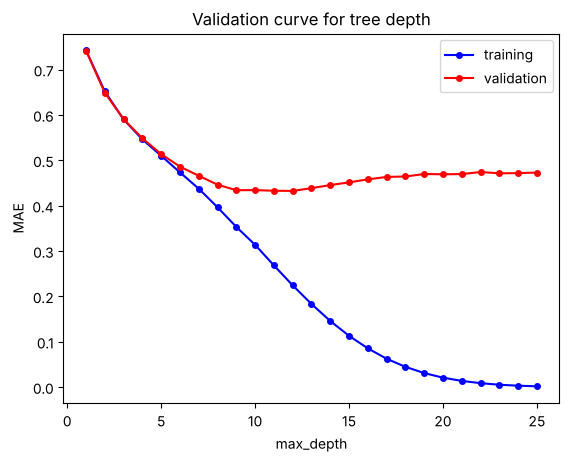

In [8]:
depths = range(1, 26)
train_scores, valid_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), train_features, train_labels,
    param_name="max_depth", param_range=depths, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)

plt.plot(depths, -train_scores.mean(axis=1), 'b-o', ms=4, label='training')
plt.plot(depths, -valid_scores.mean(axis=1), 'r-o', ms=4, label='validation')
plt.xlabel('max_depth'); plt.ylabel('MAE'); plt.legend()
plt.title('Validation curve for tree depth')
plt.show()

* Up to about depth 8-10 both errors fall together: the tree is learning real structure.
* After that training error keeps falling towards 0 while validation error flattens and then gets worse.
  A fully grown tree (no `max_depth`) puts almost every sample in its own leaf and memorises the training
  set, a training MAE of 0 in the course ensemble colab.

## Tuning

Grid search over depth and `min_samples_split` (the minimum number of samples a node needs before it's
allowed to split).

In [9]:
param_grid = {'max_depth': range(1, 20), 'min_samples_split': range(2, 8)}
dt_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=param_grid, cv=cv,
                         scoring="neg_mean_absolute_error", return_train_score=True, n_jobs=-1)
dt_search.fit(train_features, train_labels)

i = dt_search.best_index_
print("best params:", dt_search.best_params_)
print(f"train MAE: {-dt_search.cv_results_['mean_train_score'][i]:.3f} +/- {dt_search.cv_results_['std_train_score'][i]:.3f}")
print(f"valid MAE: {-dt_search.cv_results_['mean_test_score'][i]:.3f} +/- {dt_search.cv_results_['std_test_score'][i]:.3f}")

best params: {'max_depth': 11, 'min_samples_split': 5}
train MAE: 0.279 +/- 0.005
valid MAE: 0.430 +/- 0.010


(The course version reported `std_train_score` for both lines.)

`GridSearchCV` refits the best model on the whole training set by default (`refit=True`), so there's no
need to set the parameters by hand and fit again:

In [10]:
report(dt_search.best_estimator_, test_features, test_labels)

MAE: 0.425   MSE: 0.416   R2: 0.686


Test MAE drops from about 0.60 (depth 3) to about 0.42, better than linear regression (0.53) and roughly
level with polynomial ridge.

## Cost complexity pruning

Another way to control size: grow the full tree, then prune back the branches that add the least. The
`ccp_alpha` parameter sets how much each extra leaf has to improve the fit to be worth keeping. Bigger
alpha, smaller tree.

`cost_complexity_pruning_path` lists the alphas at which the tree changes. On 15k samples there are
thousands of them, so a subset spread across the range is used.

number of candidate alphas: 13910


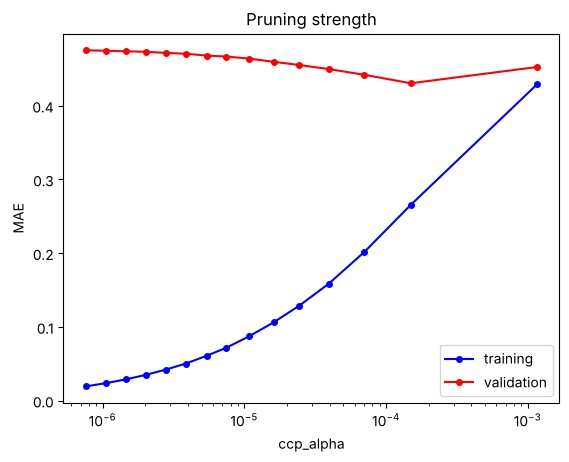

best ccp_alpha: 1.50e-04, leaves: 753, depth: 20
MAE: 0.427   MSE: 0.435   R2: 0.671


In [11]:
path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(train_features, train_labels)
print("number of candidate alphas:", len(path.ccp_alphas))

alphas = np.quantile(path.ccp_alphas, np.linspace(0.5, 0.995, 15))
train_scores, valid_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), train_features, train_labels,
    param_name="ccp_alpha", param_range=alphas, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)

plt.semilogx(alphas, -train_scores.mean(axis=1), 'b-o', ms=4, label='training')
plt.semilogx(alphas, -valid_scores.mean(axis=1), 'r-o', ms=4, label='validation')
plt.xlabel('ccp_alpha'); plt.ylabel('MAE'); plt.legend()
plt.title('Pruning strength')
plt.show()

best_alpha = alphas[np.argmax(valid_scores.mean(axis=1))]
pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha).fit(train_features, train_labels)
print(f"best ccp_alpha: {best_alpha:.2e}, leaves: {pruned.get_n_leaves()}, depth: {pruned.get_depth()}")
report(pruned, test_features, test_labels)

Pruning ends up in the same place as limiting depth, with a tree that can be deep in some branches and
shallow in others, rather than the same maximum depth everywhere.

## Feature importances

How much each feature reduced the squared error across all the splits it was used in, normalised to sum to 1.

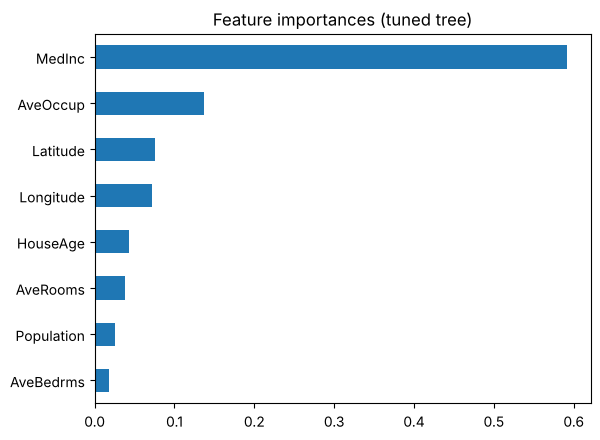

In [12]:
imp = pd.Series(dt_search.best_estimator_.feature_importances_, index=features.columns).sort_values()
imp.plot.barh()
plt.title('Feature importances (tuned tree)')
plt.show()

MedInc first, then location (AveOccup, Latitude, Longitude). Unlike linear regression, the tree can use
latitude and longitude together to carve out expensive regions.

These impurity-based importances are biased towards features with many possible split points, so for
anything serious `sklearn.inspection.permutation_importance` is more reliable.

## Summary (regression)

* trees need no scaling and capture non-linear effects and interactions
* depth (or `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `ccp_alpha`) controls the
  bias/variance trade-off: shallow trees underfit, unrestricted trees memorise the training data
* a tuned tree beats linear regression here (MAE about 0.42 vs 0.53)
* single trees are unstable: small changes in data can change the splits a lot. Averaging many trees fixes
  that, which is what the ensemble notebooks are about

---

# Part 2: classification trees

Same structure, but each leaf predicts the **majority class** of its training samples, and splits are chosen
to make the child nodes as pure as possible. Two common impurity measures for a node with class proportions
$p_k$:

* **Gini** (default): $1 - \sum_k p_k^2$. 0 for a pure node, 0.5 for a 50/50 binary split.
* **Entropy**: $-\sum_k p_k \log_2 p_k$. 0 for a pure node, 1 for a 50/50 binary split.

They almost always pick the same splits.

## Iris

In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xi_train, yi_train)
print(classification_report(yi_test, dt_clf.predict(Xi_test), target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



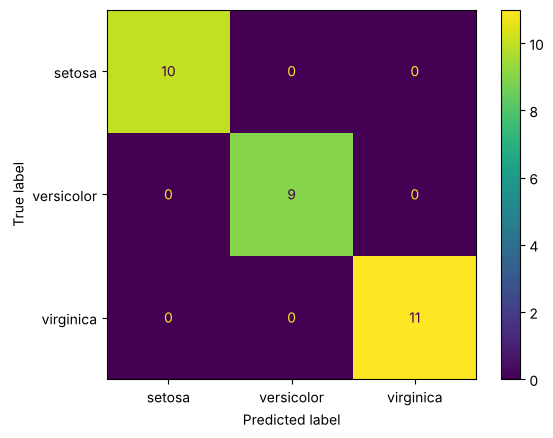

In [14]:
ConfusionMatrixDisplay.from_estimator(dt_clf, Xi_test, yi_test, display_labels=iris.target_names)
plt.show()

100% on this particular test set, but that's only 30 flowers. Cross validation below gives a more honest
number.

The course pipeline had a `MinMaxScaler` in front of the tree. As with regression, it changes nothing about
the model and makes the printed thresholds unreadable (`petal length <= 0.25` instead of real centimetres),
so it's left out.

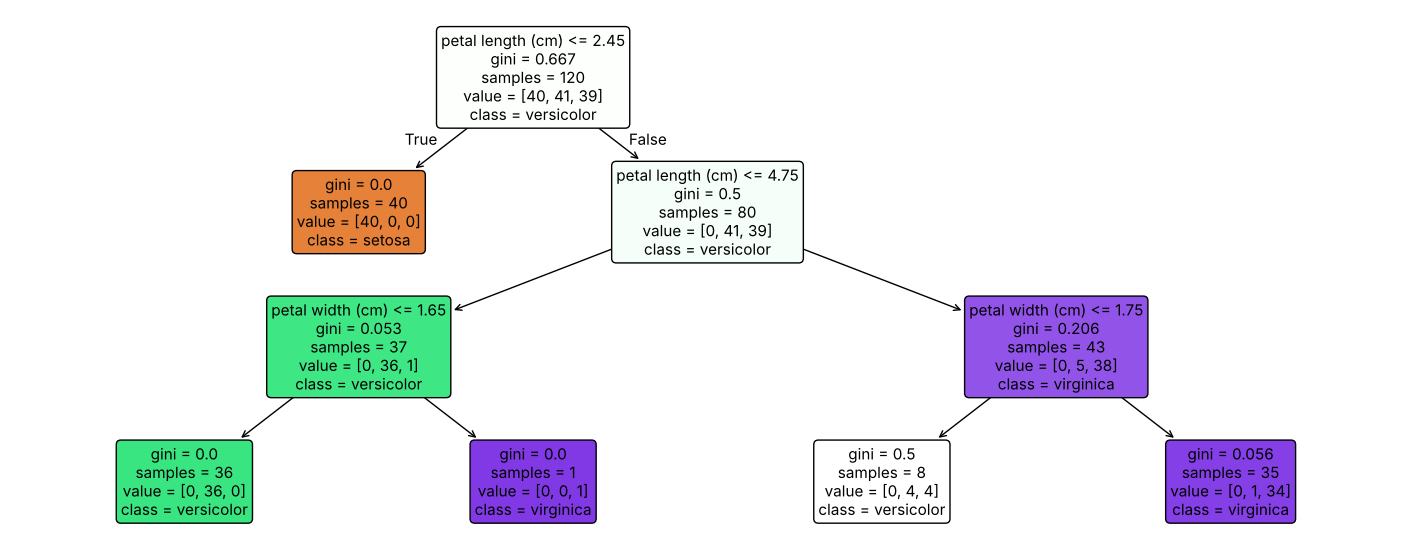

In [15]:
plt.figure(figsize=(18, 7))
plot_tree(dt_clf, feature_names=list(X_iris.columns), class_names=list(iris.target_names),
          rounded=True, filled=True, fontsize=11)
plt.show()

In [16]:
print(export_text(dt_clf, feature_names=list(X_iris.columns)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



The first split, petal length <= 2.45 cm, separates setosa perfectly (gini = 0 in that leaf). The rest of
the tree separates versicolor from virginica on petal length and width.

In [17]:
pd.Series(dt_clf.feature_importances_, index=X_iris.columns).sort_values(ascending=False).round(3)

petal length (cm)    0.935
petal width (cm)     0.065
sepal width (cm)     0.000
sepal length (cm)    0.000
dtype: float64

Only the petal features are used. Sepal measurements get importance 0.

### Tuning depth and min_samples_split

In [18]:
from sklearn.model_selection import StratifiedKFold

clf_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          {'max_depth': [1, 2, 3, 4, 5], 'min_samples_split': [2, 4, 6, 8, 10],
                           'criterion': ['gini', 'entropy']},
                          scoring='f1_macro', cv=StratifiedKFold(5, shuffle=True, random_state=0))
clf_search.fit(Xi_train, yi_train)

res = pd.DataFrame(clf_search.cv_results_)
print("best:", clf_search.best_params_, f" CV macro F1 {clf_search.best_score_:.3f}")
res[res.param_criterion == 'gini'].pivot_table(index='param_max_depth', columns='param_min_samples_split',
                                               values='mean_test_score').round(3)

best: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}  CV macro F1 0.916


param_min_samples_split,2,4,6,8,10
param_max_depth,,,,,
1,0.559,0.559,0.559,0.559,0.559
2,0.916,0.916,0.916,0.916,0.916
3,0.907,0.907,0.907,0.907,0.907
4,0.907,0.899,0.899,0.899,0.899
5,0.899,0.899,0.899,0.899,0.899


Depth 1 can only split off one class (macro F1 around 0.56), depth 2 gets about 0.92, and deeper trees do
slightly worse (0.90-0.91): iris is too easy to need a deep tree. `min_samples_split` barely matters at
this size. (The course's run picked depth 4 with a different CV split; the differences are within noise.)

## Abalone: when classification is the wrong framing

The course also trained a classification tree on abalone, predicting the number of rings directly as a
class. That's 28 classes, several with only one or two examples, for what is really a count.

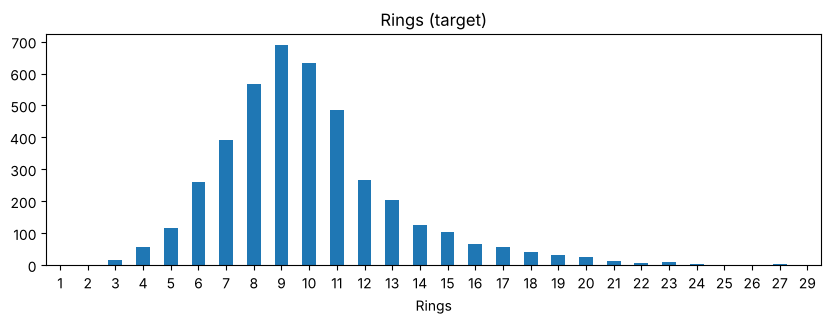

In [19]:
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
                'Viscera weight', 'Shell weight', 'Rings']
abalone = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data',
                      header=None, names=column_names)
abalone['Rings'].value_counts().sort_index().plot.bar(figsize=(10, 3), rot=0)
plt.title('Rings (target)')
plt.show()

Two rows have Height = 0, both infants. The course filled them with the mean height of infants. Here that's
done with pandas before the split (a single known fix to two rows, not something learned from the data, so
there's no leakage concern). The course pipeline did it with `SimpleImputer(missing_values=0, ...)` on *all*
numeric columns, which only worked because no other column has zeros.

In [20]:
infant_height = abalone.loc[(abalone.Sex == 'I') & (abalone.Height > 0), 'Height'].mean()
abalone.loc[abalone.Height == 0, 'Height'] = infant_height
print(f"filled with {infant_height:.6f}")

filled with 0.108157


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

X_ab = abalone.drop(columns='Rings')
num_cols = X_ab.columns.drop('Sex').tolist()
pre = ColumnTransformer([('num', 'passthrough', num_cols),
                         ('cat', OneHotEncoder(handle_unknown='ignore'), ['Sex'])])

def ab_tree(**kw):
    return Pipeline([('pre', pre), ('tree', DecisionTreeClassifier(random_state=42, **kw))])

y_rings = abalone['Rings']
Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_ab, y_rings, test_size=0.2, random_state=0)
m = ab_tree(max_depth=5, min_samples_split=4).fit(Xa_train, ya_train)
print(f"28-class accuracy: {m.score(Xa_test, ya_test):.3f}")

28-class accuracy: 0.272


About 27%, the same ballpark as the course. Looks terrible, but most mistakes are off by one or two rings,
and a classifier gets no credit for "close". Predicting 9 rings when the truth is 10 counts the same as
predicting 25.

Two better framings:

**1. Treat it as regression**, since rings are a count:

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

reg = Pipeline([('pre', pre), ('tree', DecisionTreeRegressor(max_depth=6, random_state=42))]).fit(Xa_train, ya_train)
pred_reg = reg.predict(Xa_test)
pred_cls = m.predict(Xa_test)
print(f"regression tree MAE:       {mean_absolute_error(ya_test, pred_reg):.2f} rings")
print(f"classification tree MAE:   {mean_absolute_error(ya_test, pred_cls):.2f} rings")
print(f"classifier within 1 ring:  {(abs(pred_cls - ya_test) <= 1).mean():.1%}")

regression tree MAE:       1.62 rings
classification tree MAE:   1.69 rings
classifier within 1 ring:  62.0%


The regression tree is only a little better on average error (1.62 vs 1.69 rings), but notice that 62% of
the classifier's predictions are within one ring, even though only 27% are exactly right.

**2. Group the rings into age bands** if a category is what's actually needed. A common split is young
(<= 8 rings), adult (9-10) and old (>= 11):

In [23]:
bands = pd.cut(y_rings, bins=[0, 8, 10, 30], labels=['young', 'adult', 'old'])
print(bands.value_counts().to_dict())
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_ab, bands, test_size=0.2, random_state=0, stratify=bands)

band_search = GridSearchCV(ab_tree(), {'tree__max_depth': range(2, 11), 'tree__min_samples_leaf': [1, 5, 10, 20]},
                           scoring='f1_macro', cv=5)
band_search.fit(Xb_train, yb_train)
print("best:", band_search.best_params_, f" CV macro F1 {band_search.best_score_:.3f}")
print(classification_report(yb_test, band_search.predict(Xb_test)))

{'old': 1447, 'young': 1407, 'adult': 1323}


best: {'tree__max_depth': 10, 'tree__min_samples_leaf': 20}  CV macro F1 0.634
              precision    recall  f1-score   support

       adult       0.41      0.45      0.43       265
         old       0.59      0.58      0.58       290
       young       0.74      0.69      0.71       281

    accuracy                           0.57       836
   macro avg       0.58      0.57      0.57       836
weighted avg       0.58      0.57      0.58       836



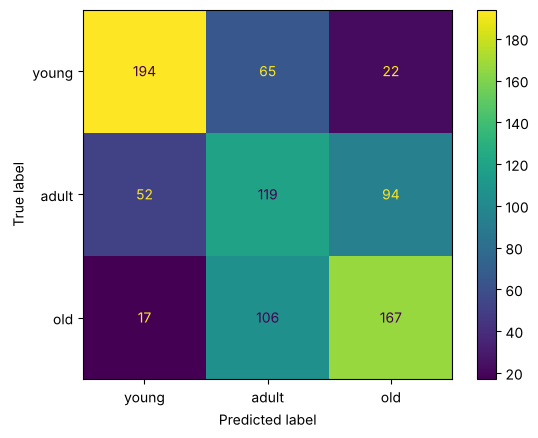

In [24]:
ConfusionMatrixDisplay.from_estimator(band_search, Xb_test, yb_test, labels=['young', 'adult', 'old'])
plt.show()

CV macro F1 about 0.63 and 57% accuracy on the test set, for three roughly balanced classes. Young and old
are mostly told apart, and "adult" sits in between
and gets confused with both, which is what you'd expect from a band cut out of the middle of a continuous
scale.

(The course grid search ran on data that had already been through the preprocessor, outside the pipeline.
With a passthrough/one-hot preprocessor that doesn't leak anything here, but searching over the whole
pipeline is the habit to keep.)

## Summary (classification)

* classification trees split to make nodes pure (Gini or entropy) and predict the majority class in a leaf
* `plot_tree` / `export_text` with `class_names` make small trees easy to explain
* tune depth with cross validation. Iris needs depth 2-3
* think about the target: a count with 28 values is better treated as regression, or grouped into bands